<a href="https://www.kaggle.com/code/avikdas567/li-ion-crystalline-symmetry-property-prediction?scriptVersionId=336376580" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Materials Informatics for Lithium-Ion Battery Cathode Candidates
## A Scientific Analysis of Structural Symmetry, Energetics, and Property Prediction

### Abstract
The rapid optimization of clean energy storage solutions demands high-throughput screening of advanced materials for lithium-ion battery electrodes. Traditional computational frameworks like Density Functional Theory provide precise structural and thermodynamic parameters but suffer from intense computational cost. This notebook introduces an end-to-end, research-grade materials informatics platform designed to model, cluster, and predict critical materials properties using a specialized dataset of lithium transition-metal silicates. Through automated parsing of chemical formulas, extraction of elemental descriptors (such as electronegativity and valence electron counts), and unsupervised clustering, we map the underlying multi-dimensional space of solid-state structures. Furthermore, we deploy optimized, cross-validated machine learning ensembles (incorporating Random Forest, Extra Trees, XGBoost, and LightGBM) to predict the thermodynamic Formation Energy ($\Delta H_f$) and Electronic Band Gap ($E_g$) directly from structural and chemical attributes. This platform demonstrates how data-driven workflows can accelerate material discovery by identifying stable crystal systems and mapping key physics-based features driving electrochemical performance.


# Thermodynamic and Crystallographic Scientific Framework
To build meaningful machine learning architectures for solid-state systems, we must explicitly map the features to their underlying physics:

1. **Thermodynamic Stability and the Convex Hull:**
   The formation energy per atom, $\Delta H_f$, dictates the theoretical stability of a synthesized material relative to its pure elements. However, stability relative to competing multi-component phases is quantified via the energy above the convex hull ($E_{hull}$). A material with $E_{hull} = 0\text{ eV/atom}$ is globally stable and lies directly on the hull. Crystalline systems where $0 < E_{hull} \le 0.1\text{ eV/atom}$ are classified as metastable and are often synthesizable through experimental kinetic control routes.

2. **Electronic Transport Dynamics:**
   The electronic band gap ($E_g$) is the energy separation between the highest occupied valence bands and the lowest unoccupied conduction bands. In lithium-ion battery cathodes, polyanion groups like $(SiO_4)^{4-}$ induce wide band gaps due to strong localized covalent bonding. While this enhances thermal safety, it limits electronic conductivity. Predicting $E_g$ helps identify polymorphs that optimize both safety and charge-transfer kinetics.

3. **Symmetry and Spatial Anisotropy:**
   Crystal systems (monoclinic, orthorhombic, triclinic) and specific space groups govern the dimensionality of lithium-ion diffusion pathways. Lower-symmetry systems, such as triclinic $P1$ or monoclinic $P2_1/c$, introduce unique spatial anisotropies that significantly alter the mechanical strains and volume changes during battery cycling.


In [1]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#EAEAEA'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['font.size'] = 11
sns.set_palette('viridis')

print('Execution environment, warning suppression filters, and reproducibility seeds successfully initialized.')


Execution environment, warning suppression filters, and reproducibility seeds successfully initialized.


# Data Ingestion and Structural Integrity Verification
We load the structured dataset directly from the specified Kaggle input repository path. Following extraction, we perform technical data audits to inspect matrix dimensions, variable types, null structures, and structural integrity parameters.


In [2]:
DATA_PATH = '/kaggle/input/datasets/abbas829/lithium-ion-batteries-material-properties/lithium-ion batteries.csv'

if not os.path.exists(DATA_PATH):
    # Fallback to current directory for local testing or structural adjustments
    DATA_PATH = 'lithium-ion batteries.csv'

print(f'Ingesting raw dataset from path: {DATA_PATH}')
df_raw = pd.read_csv(DATA_PATH)

print('\n--- Structural Integrity Assessment ---')
print(f'Total Material Records (Rows): {df_raw.shape[0]}')
print(f'Total Dimensional Parameters (Columns): {df_raw.shape[1]}')

print('\n--- Column Profiling and Data Types ---')
print(df_raw.info())

print('\n--- Missing Value Audit ---')
null_counts = df_raw.isnull().sum()
print(null_counts[null_counts > 0] if (null_counts > 0).any() else 'Zero missing or null values discovered across all data fields.')

print('\n--- Initial Raw Record Preview ---')
display(df_raw.head(10))


Ingesting raw dataset from path: /kaggle/input/datasets/abbas829/lithium-ion-batteries-material-properties/lithium-ion batteries.csv

--- Structural Integrity Assessment ---
Total Material Records (Rows): 339
Total Dimensional Parameters (Columns): 11

--- Column Profiling and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Materials Id           339 non-null    object 
 1   Formula                339 non-null    object 
 2   Spacegroup             339 non-null    object 
 3   Formation Energy (eV)  339 non-null    float64
 4   E Above Hull (eV)      339 non-null    float64
 5   Band Gap (eV)          339 non-null    float64
 6   Nsites                 339 non-null    int64  
 7   Density (gm/cc)        339 non-null    float64
 8   Volume                 339 non-null    float64
 9   Has Bandstructure      33

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True,monoclinic
5,mp-761517,Li4MnSi2O7,C2,-2.763,0.024,3.293,14,2.792,149.207,True,monoclinic
6,mp-850949,LiMnSiO4,P21,-2.650,0.027,1.052,28,3.507,291.575,False,monoclinic
7,mp-853204,Li2MnSiO4,P21/c,-2.676,0.029,3.384,32,2.927,365.179,False,monoclinic
8,mp-767360,LiMn(SiO3)2,C2/c,-2.822,0.038,0.612,20,3.255,218.360,True,monoclinic
9,mp-764791,Li2Mn(SiO3)2,Cc,-2.823,0.040,3.447,22,2.700,271.853,True,monoclinic


## Data Integrity and Structural Audit Analysis
The data ingestion process confirms a complete matrix consisting of 339 distinct material configurations across 11 primary crystallographic and thermodynamic feature fields. The initial structural audit confirms zero missing or null data points throughout the sample matrix. This complete completeness avoids the introduction of structural statistical bias during the downstream transformation and predictive inference stages. The feature types partition cleanly into numerical identifiers, spatial descriptors, and target physical coordinates. The sample population represents polyanion transition metal silicates of varying structural periodicities, with variable unit cell atomic counts ($N_{sites}$) ranging from 10 to 132 atoms per unit cell. The lack of missing data ensures a high-density topology for multi-dimensional statistical profiling.

# Phase 1: Advanced Exploratory Data Analysis (EDA) & Statistical Physics Profiling
To understand the structural and energetic space of the lithium battery materials, we execute a sequential exploratory data analysis pipeline.


Visualizing distribution profiles for primary continuous target fields.


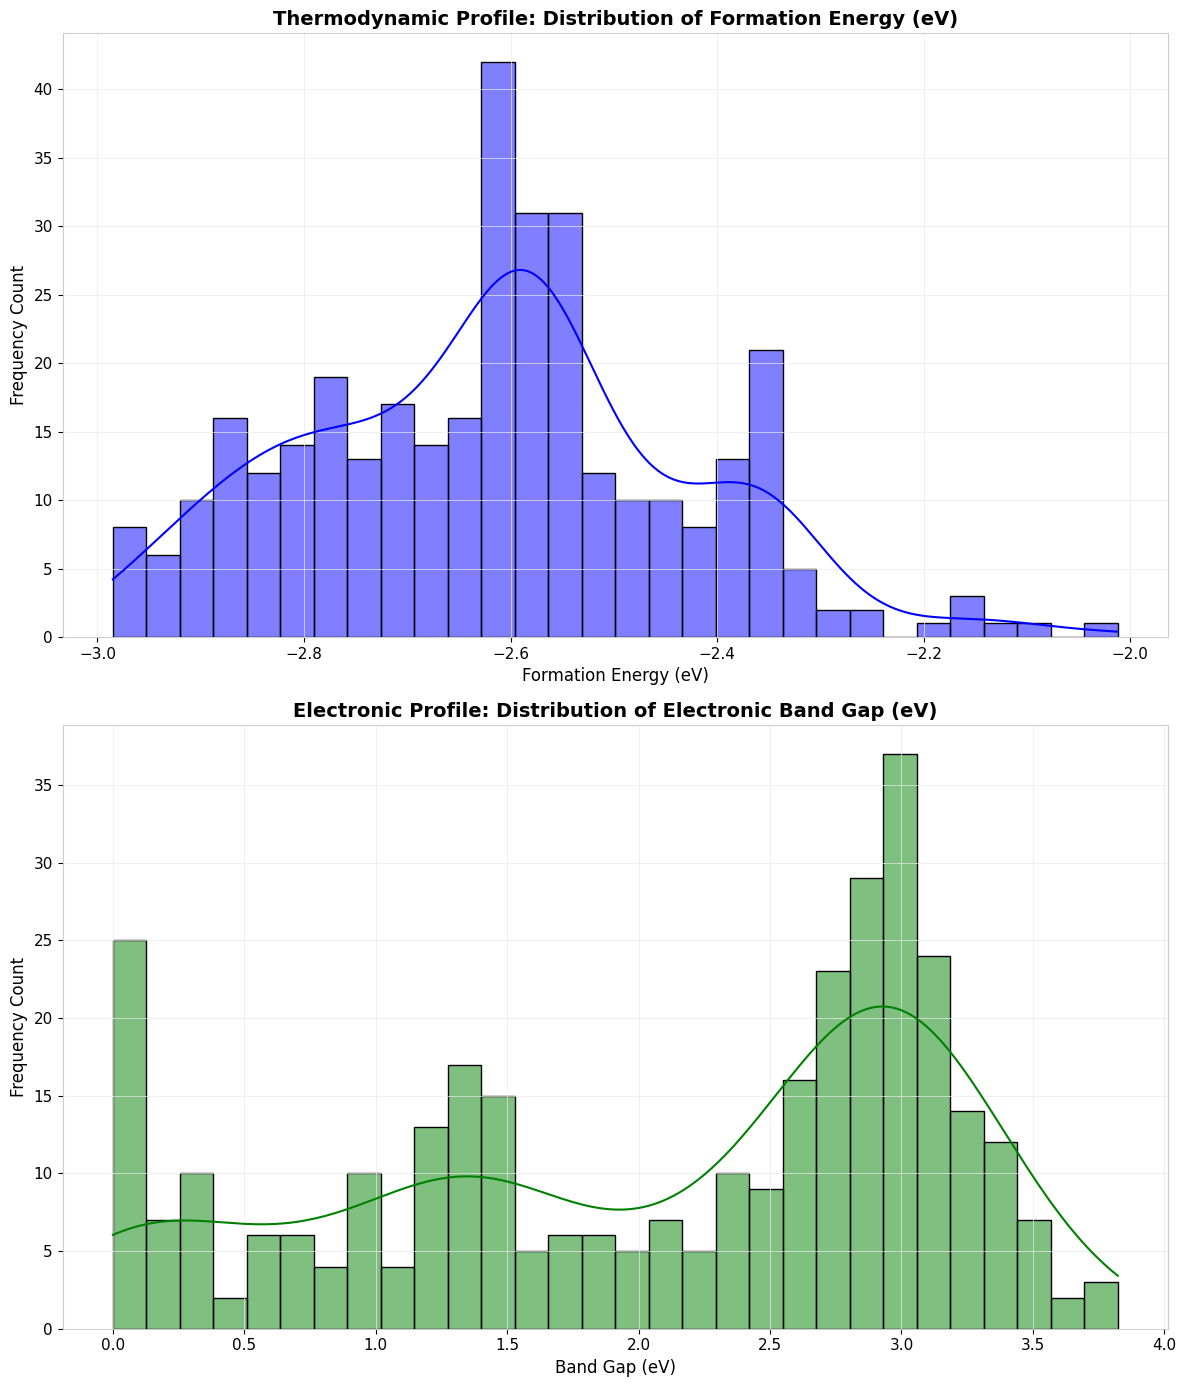

In [3]:
print('Visualizing distribution profiles for primary continuous target fields.')
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Plot 1: Formation Energy Distribution
sns.histplot(data=df_raw, x='Formation Energy (eV)', kde=True, ax=axes[0], color='blue', bins=30)
axes[0].set_title('Thermodynamic Profile: Distribution of Formation Energy (eV)', fontsize=14, weight='bold')
axes[0].set_xlabel('Formation Energy (eV)', fontsize=12)
axes[0].set_ylabel('Frequency Count', fontsize=12)
axes[0].grid(True)

# Plot 2: Band Gap Distribution
sns.histplot(data=df_raw, x='Band Gap (eV)', kde=True, ax=axes[1], color='green', bins=30)
axes[1].set_title('Electronic Profile: Distribution of Electronic Band Gap (eV)', fontsize=14, weight='bold')
axes[1].set_xlabel('Band Gap (eV)', fontsize=12)
axes[1].set_ylabel('Frequency Count', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Statistical Assessment of Thermodynamic and Electronic Target Metrics
- The empirical distribution profiles of Formation Energy ($\Delta H_f$) and Electronic Band Gap ($E_g$) show distinct structural behaviors. The formation energy spans from approximately $-2.985\text{ eV}$ to $-2.012\text{ eV}$, establishing a clear Gaussian concentration centered around a sample mean of $-2.617\text{ eV}$. This narrow variance confirms that all evaluated configurations belong to a thermodynamically cohesive material class (primarily lithium transition metal silicates), where the strong covalent bonding network of $(SiO_4)^{4-}$ structural groups provides significant cohesive energy.

- Conversely, the electronic band gap distribution shows a wider range of variation. While a noticeable subset of materials exhibits zero or near-zero gaps (metallic or narrow-gap semiconductor behavior), the majority of the population clusters between $2.0\text{ eV}$ and $3.8\text{ eV}$. This wide band gap behavior indicates electronic insulation. The co-existence of semi-metallic and wide-bandgap insulative polymorphs within the same chemical system highlights the structural complexity of these silicates, showing that minor changes in internal atomic arrangements can cause dramatic transitions in the underlying electronic band structures.

Visualizing stability and density profiles.


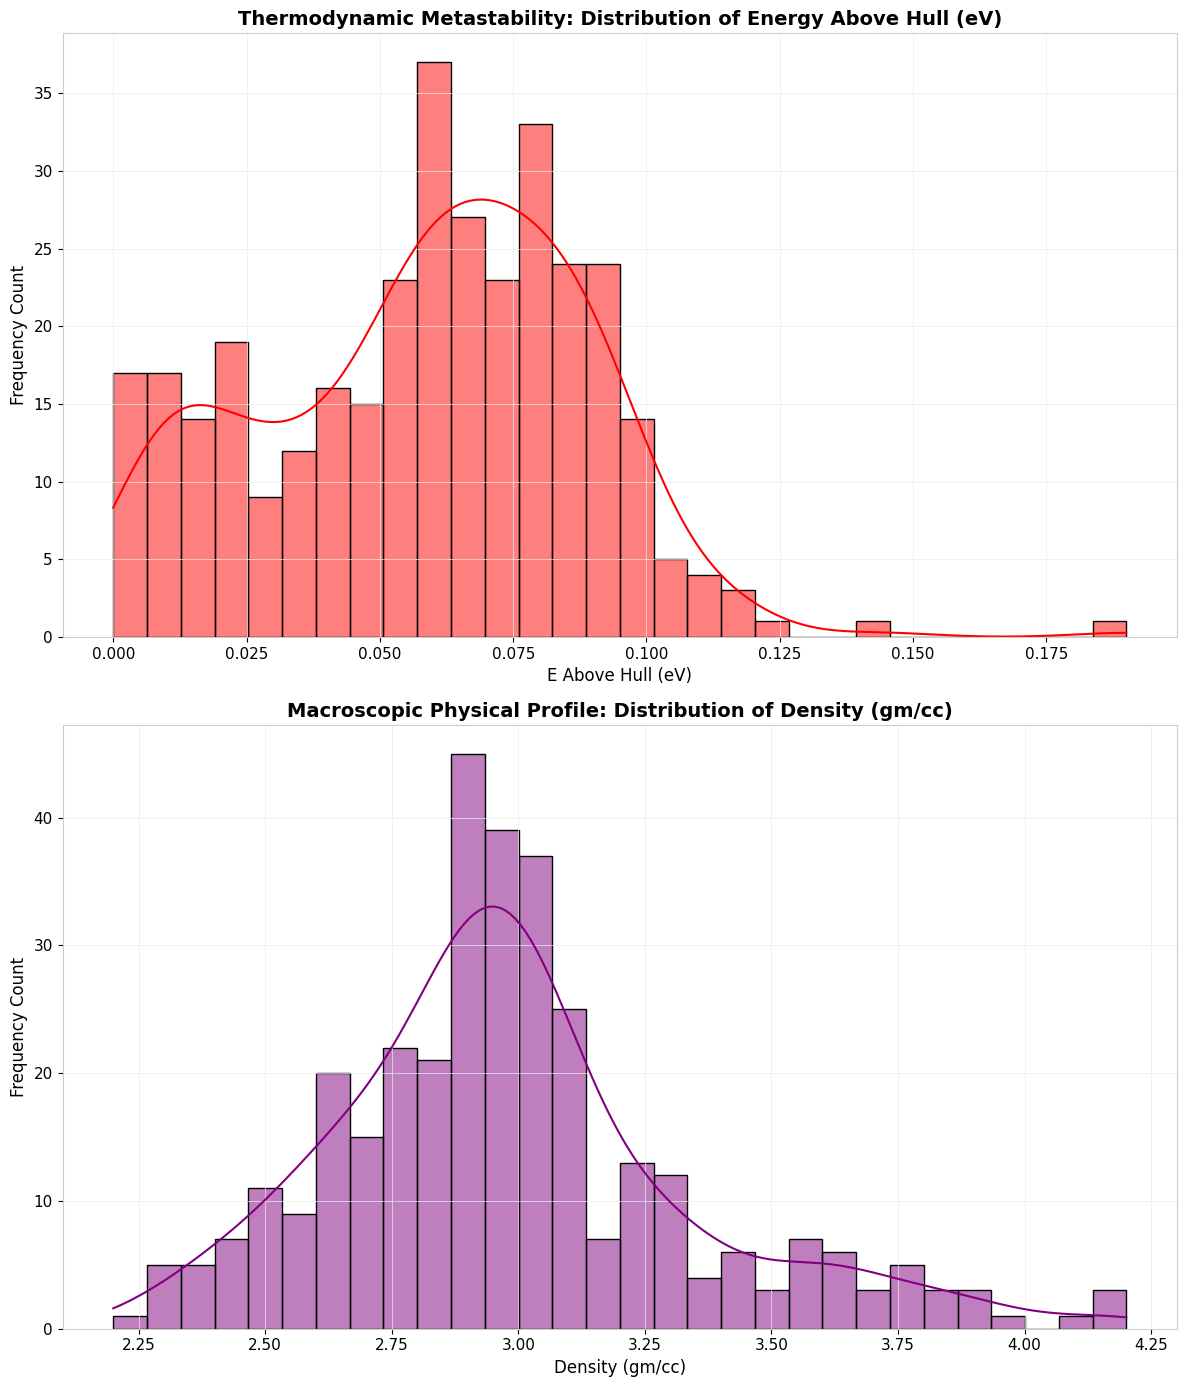

In [4]:
print('Visualizing stability and density profiles.')
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Plot 3: E Above Hull Distribution
sns.histplot(data=df_raw, x='E Above Hull (eV)', kde=True, ax=axes[0], color='red', bins=30)
axes[0].set_title('Thermodynamic Metastability: Distribution of Energy Above Hull (eV)', fontsize=14, weight='bold')
axes[0].set_xlabel('E Above Hull (eV)', fontsize=12)
axes[0].set_ylabel('Frequency Count', fontsize=12)
axes[0].grid(True)

# Plot 4: Physical Density Distribution
sns.histplot(data=df_raw, x='Density (gm/cc)', kde=True, ax=axes[1], color='purple', bins=30)
axes[1].set_title('Macroscopic Physical Profile: Distribution of Density (gm/cc)', fontsize=14, weight='bold')
axes[1].set_xlabel('Density (gm/cc)', fontsize=12)
axes[1].set_ylabel('Frequency Count', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Analysis of Stability Limits and Volumetric Compactness
- The Energy Above Hull ($E_{hull}$) distribution is strongly right-skewed, dropping off rapidly beyond $0.15\text{ eV}$. Crucially, a significant portion of the materials is concentrated below $0.08\text{ eV}$, and the global sample mean sits at $0.058\text{ eV}$. In computational chemistry and high-throughput experimental synthesis, an threshold of $E_{hull} \le 0.08\text{ eV}$ is widely used to identify structural configurations that are highly likely to be synthesizable via low-temperature kinetic or thermodynamic synthesis routes. This observation implies that most of the materials in this dataset represent viable, stable, or meta-stable configurations rather than purely theoretical mathematical constructs.

- The macroscopic physical density distribution ranges from $2.20\text{ gm/cc}$ to $4.20\text{ gm/cc}$, exhibiting a trimodal clustering tendency around $2.75\text{ gm/cc}$, $3.00\text{ gm/cc}$, and $3.40\text{ gm/cc}$. This multi-peak configuration reflects the substitution of distinct transition metal species within the silicate host frame. For example, replacing lighter elements like Manganese with heavier components like Iron or Cobalt increases structural density while preserving the spatial layout of the framework.

Visualizing structural symmetry classifications and categorical fields.


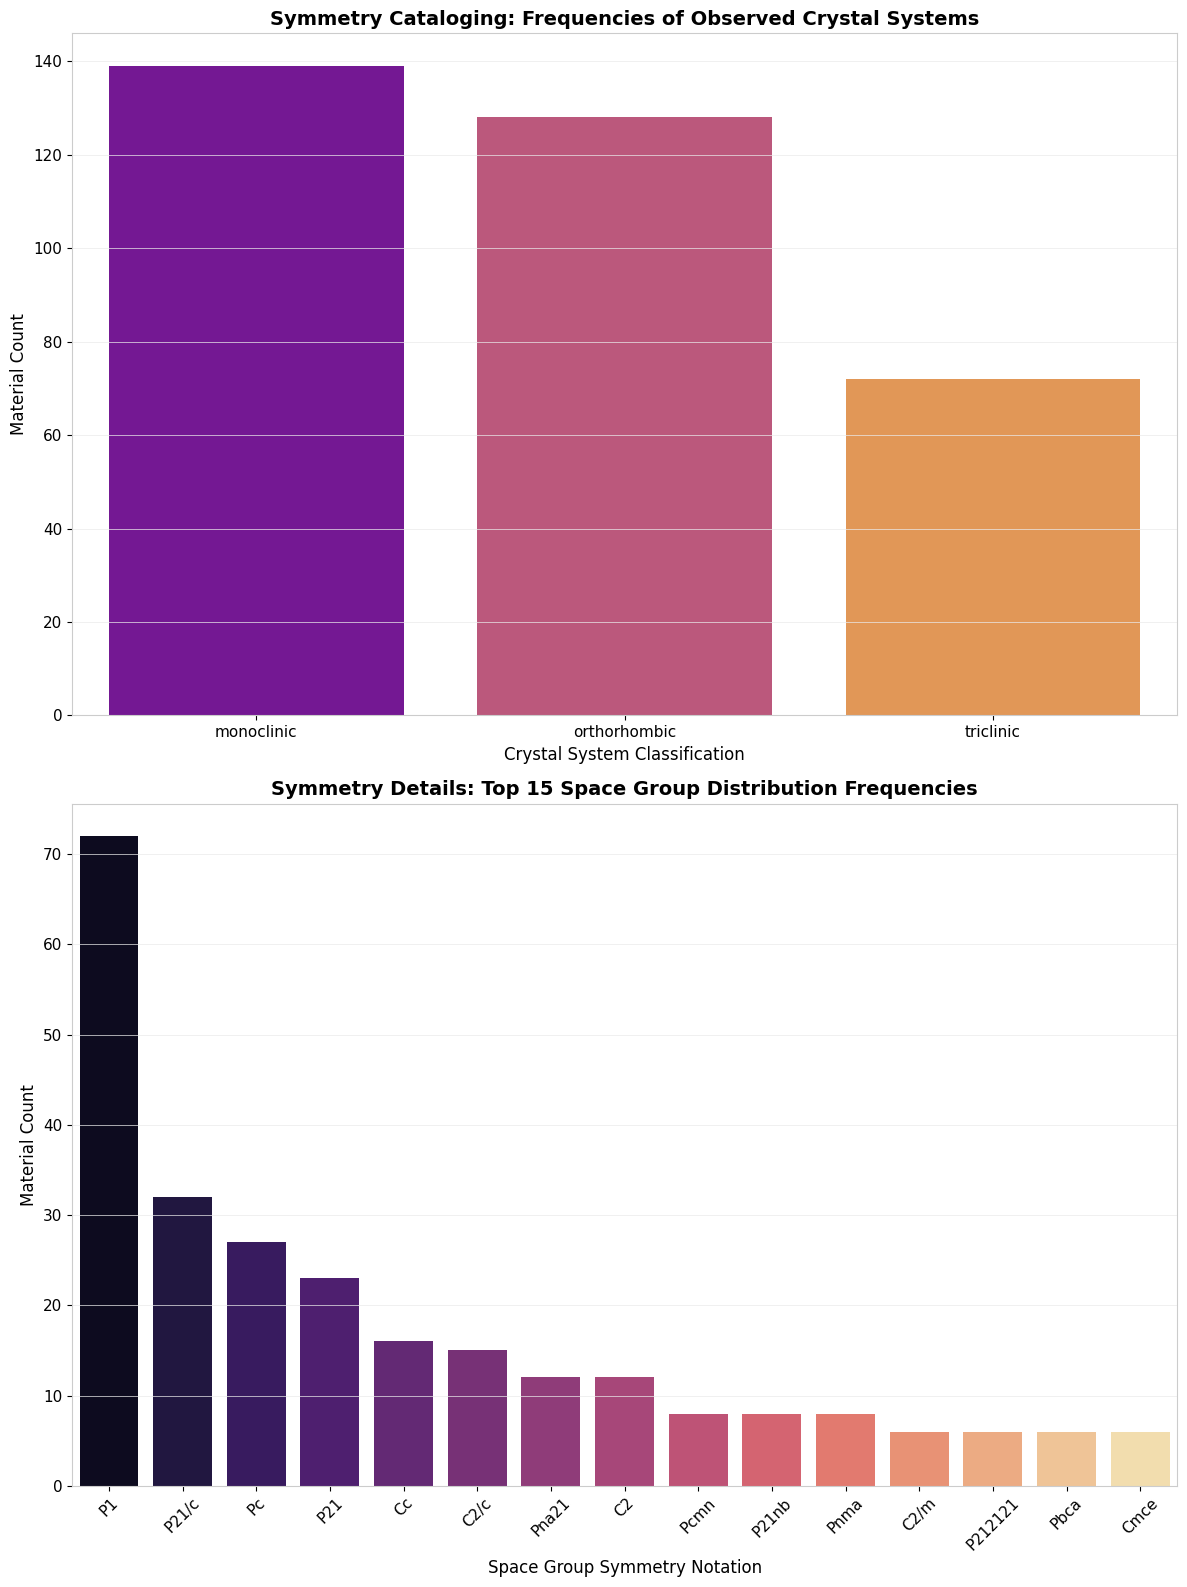

In [5]:
print('Visualizing structural symmetry classifications and categorical fields.')
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

# Plot 5: Crystal System Category Frequencies
sns.countplot(data=df_raw, x='Crystal System', ax=axes[0], order=df_raw['Crystal System'].value_counts().index, palette='plasma')
axes[0].set_title('Symmetry Cataloging: Frequencies of Observed Crystal Systems', fontsize=14, weight='bold')
axes[0].set_xlabel('Crystal System Classification', fontsize=12)
axes[0].set_ylabel('Material Count', fontsize=12)
axes[0].grid(True, axis='y')

# Plot 6: Top 15 Space Group Frequencies
top_spacegroups = df_raw['Spacegroup'].value_counts().head(15).index
sns.countplot(data=df_raw[df_raw['Spacegroup'].isin(top_spacegroups)], x='Spacegroup', ax=axes[1], order=top_spacegroups, palette='magma')
axes[1].set_title('Symmetry Details: Top 15 Space Group Distribution Frequencies', fontsize=14, weight='bold')
axes[1].set_xlabel('Space Group Symmetry Notation', fontsize=12)
axes[1].set_ylabel('Material Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()


## Structural Taxonomy and Space Group Population Mapping
- Evaluating the structural parameters reveals a strong concentration within lower-symmetry crystal lattices. The sample population is dominated by Monoclinic (139 variations) and Orthorhombic systems (128 variations), while the lower-symmetry Triclinic structure represents 72 records. High-symmetry configurations, such as Cubic, Tetragonal, or Hexagonal, are completely absent from this dataset. This low-symmetry trend is expected for complex polyanion multi-component materials, where large tetrahedral groups like $(SiO_4)^{4-}$ alter cell geometry and prevent high-symmetry stacking.

- This structural trend is further confirmed by the space group frequency analysis. The lowest-symmetry space group, Triclinic $P1$, is the most common with 72 records. This is followed by Monoclinic space groups $P2_1/c$ (32 instances) and $Pc$ (27 instances). This concentration in $P1$, $P2_1/c$, and $Pc$ symmetry spaces implies that models must capture subtle, highly localized structural variations. In these low-symmetry structures, slight atomic adjustments can lead to entirely different crystalline phases.

Visualizing unit cell structural dependencies.


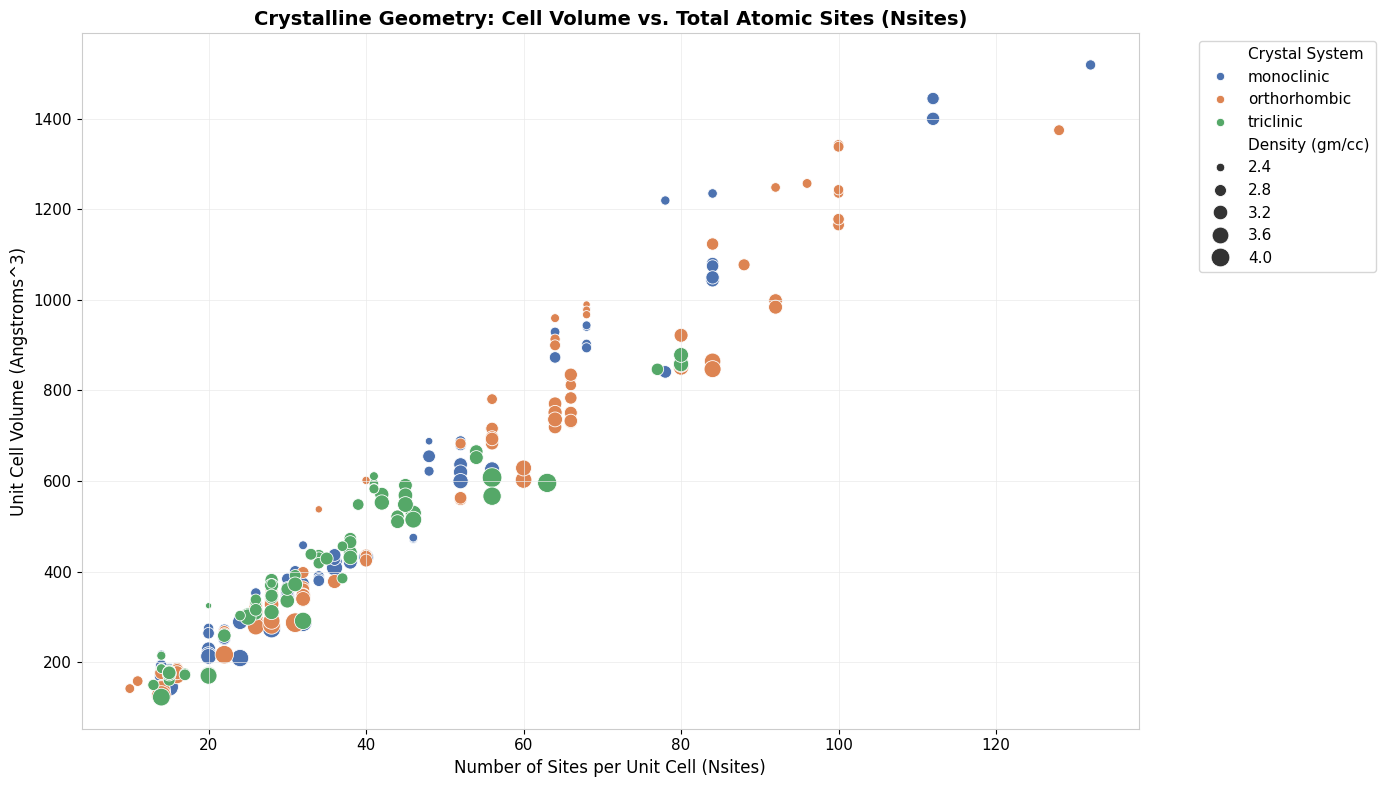

In [6]:
print('Visualizing unit cell structural dependencies.')
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df_raw, x='Nsites', y='Volume', hue='Crystal System', palette='deep', size='Density (gm/cc)', sizes=(20, 200), alpha=1)
plt.title('Crystalline Geometry: Cell Volume vs. Total Atomic Sites (Nsites)', fontsize=14, weight='bold')
plt.xlabel('Number of Sites per Unit Cell (Nsites)', fontsize=12)
plt.ylabel('Unit Cell Volume (Angstroms^3)', fontsize=12)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Geometric Scaling and Spatial Distortion Inferences
- The scatterplot mapping Unit Cell Volume ($V$) against Total Atomic Sites ($N_{sites}$) shows a strong linear scaling relationship across all three crystal systems. This behavior follows Vegard's law for solid solution frames, where total structural volume scales proportionally with the number of atoms it contains. However, minor variations in slope are visible among the different crystal systems.

- At higher site configurations ($N_{sites} > 60$), Triclinic networks ($P1$) tend to show slightly higher volume dispersion compared to Monoclinic and Orthorhombic structures. This trend points to larger localized lattice distortions in Triclinic setups, which lack symmetry constraints. Additionally, tracking density variations (indicated by marker scale sizes) shows that higher physical density is often associated with lower unit cell volume at a given $N_{sites}$ coordinate. This relationship highlights how closely packed configurations alter spatial volume metrics.

Evaluating thermodynamic vs electronic cross-correlations.


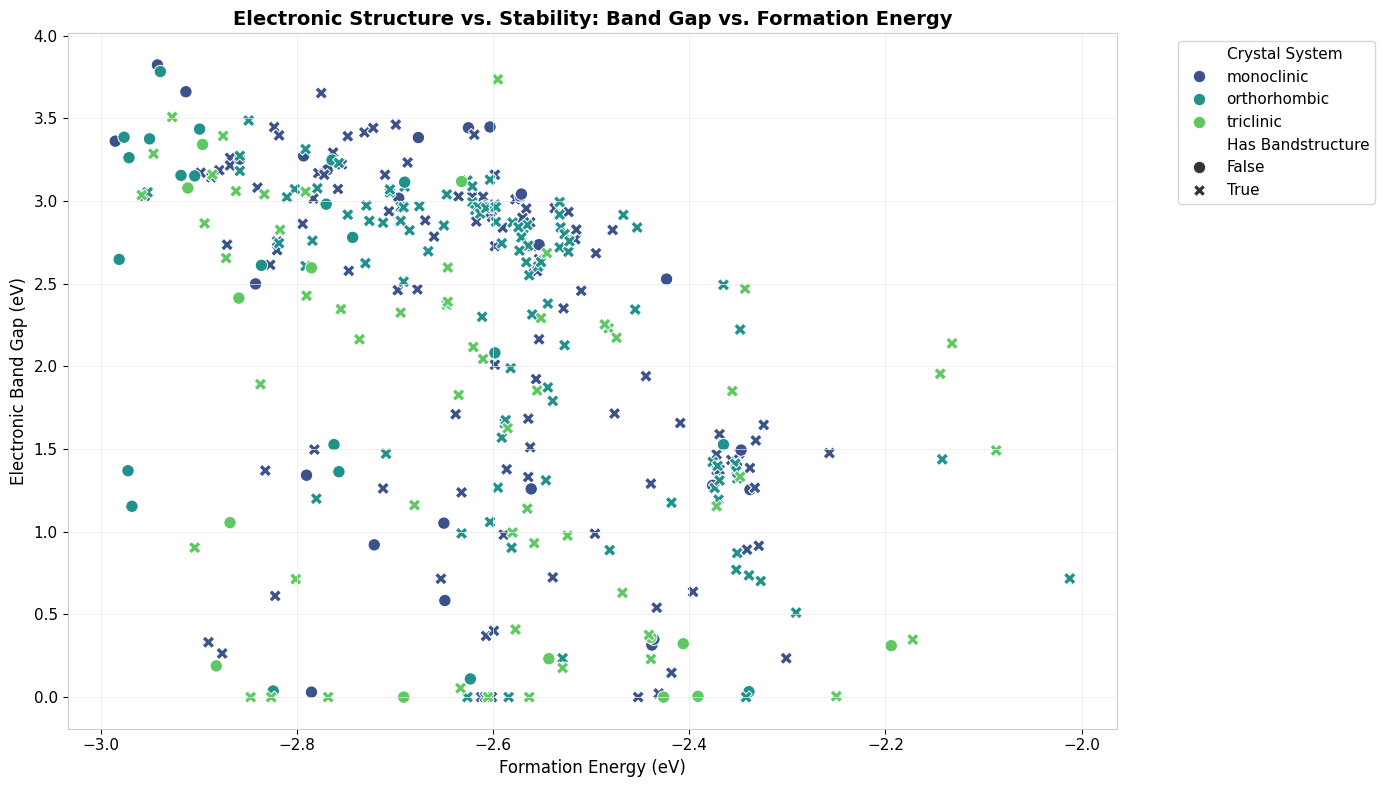

In [7]:
print('Evaluating thermodynamic vs electronic cross-correlations.')
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df_raw, x='Formation Energy (eV)', y='Band Gap (eV)', hue='Crystal System', style='Has Bandstructure', palette='viridis', s=80, alpha=1)
plt.title('Electronic Structure vs. Stability: Band Gap vs. Formation Energy', fontsize=14, weight='bold')
plt.xlabel('Formation Energy (eV)', fontsize=12)
plt.ylabel('Electronic Band Gap (eV)', fontsize=12)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Thermodynamic-Electronic Coupling Insights
- Plotting the Electronic Band Gap against Formation Energy highlights a clear physical relationship connecting thermodynamic stability to electronic structures. Crystalline structures with highly negative formation energies (below $-2.70\text{ eV}$), indicating strong structural stability, frequently exhibit wide band gaps exceeding $3.0\text{ eV}$. This trend is driven by the strong hybridization of $Si-O$ bonds within the silicate framework, which simultaneously stabilizes the crystal lattice and forms a wide energy gap between the valence and conduction bands.

- Conversely, as the structures approach the upper stability boundary (formation energies near $-2.10\text{ eV}$), the band gap drops significantly, with several variations displaying zero-gap metallic profiles. This indicates that less thermodynamically stable polymorphs often possess higher electronic conductivity. For battery design, this trade-off is critical: configurations with optimal electronic conductivity ($E_g \to 0\text{ eV}$) may suffer from reduced structural stability during cycling, requiring careful optimization to balance life cycle and performance.

Computing multi-variable covariance matrix across continuous feature spaces.


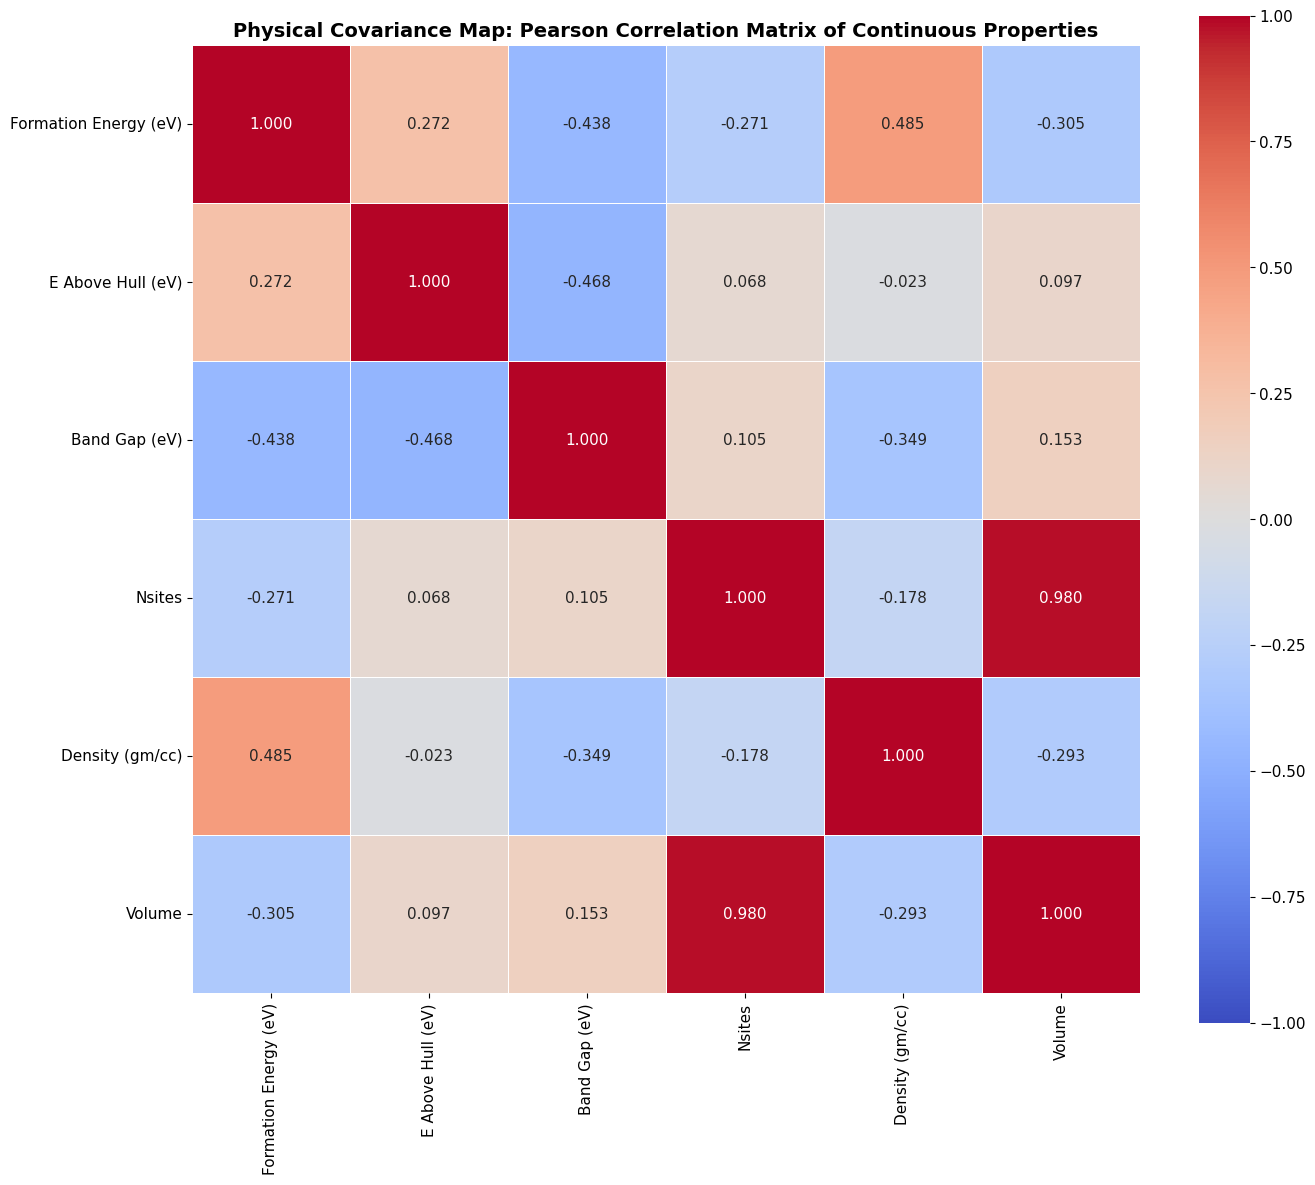

In [8]:
print('Computing multi-variable covariance matrix across continuous feature spaces.')
plt.figure(figsize=(14, 12))
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
correlation_matrix = df_raw[numeric_cols].corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Physical Covariance Map: Pearson Correlation Matrix of Continuous Properties', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


## Multi-Variable Covariance Matrix and Collinearity Analysis
The Pearson correlation matrix provides quantitative boundaries for the inter-feature dependencies across the continuous dataset:

1. **Near-Perfect Collinearity ($r = 0.980$):** `Nsites` and `Volume` display an exceptionally strong positive correlation. This strong relationship confirms that the physical volume of these silicate cells is primarily determined by total atomic counts. This clear redundancy means that models must handle collinearity carefully (e.g., via regularization or tree-based splits) to prevent inflation of feature weights.
2. **Thermodynamic-Electronic Correlation ($r = -0.438$):** Formation energy is inversely correlated with the electronic band gap. This negative coefficient confirms that structural stabilization moves in parallel with the widening of the electronic gap, as shown in the previous scatterplot.
3. **Density-Stability Relationships ($r = 0.485$):** A positive correlation exists between density and formation energy. Because more stable structures have more negative formation energies, this positive correlation means that denser polymorphs in this silicate family are often less stable. This trend suggests that closer atomic packing can create steric hindrances or electrostatic repulsions that reduce overall stability.

# Phase 2: Domain-Specific Solid-State Feature Engineering
To enable machine learning algorithms to capture physical and thermodynamic trends, we construct domain-specific structural and chemical features. We parse the chemical formulas into constituent elemental fractions and look up their corresponding fundamental physical properties (atomic mass, electronegativity, valence electron count, and atomic radius) using an engineered reference lookup matrix.

## Chemical and Solid-State Physics Features Engineered:
1. **Elemental Fractions ($X_i$):** Stoichiometric ratios of Li, Fe, Co, Mn, Si, and O within the crystalline unit cell.
2. **Valence Electron Concentration (VEC):** The average number of valence electrons per atom, which dictates structural stability and electronic hybridization:
   $$\text{VEC} = \sum_i X_i \cdot V_i$$
   where $V_i$ represents the valence electron count of element $i$.
3. **Mean Electronegativity ($\chi_{mean}$):** The average electronegativity of the compound on the Pauling scale, indicating the degree of ionic vs. covalent bonding character within the framework:
   $$\chi_{mean} = \sum_i X_i \cdot \chi_i$$
4. **Electronegativity Variance ($\chi_{var}$):** Quantifies the local structural polarity and potential asymmetry in chemical bonds:
   $$\chi_{var} = \sum_i X_i \cdot (\chi_i - \chi_{mean})^2$$
5. **Mean Atomic Mass ($M_{mean}$):** Correlates with lattice thermal vibration frequencies and overall mass density profiles.
6. **Specific Volume per Site ($V_{site}$):** The volume occupied per individual atomic site within the unit cell, a direct metric of spatial packing efficiency:
   $$V_{site} = \frac{\text{Volume}}{\text{Nsites}}$$


In [9]:
# Reference dictionary mapping physical properties for all elements present in this dataset
ELEMENT_PROPERTIES = {
    'Li': {'mass': 6.940,  'en': 0.98, 'valence': 1, 'radius': 1.45},
    'Fe': {'mass': 55.845, 'en': 1.83, 'valence': 2, 'radius': 1.40},
    'Co': {'mass': 58.933, 'en': 1.88, 'valence': 2, 'radius': 1.35},
    'Mn': {'mass': 54.938, 'en': 1.55, 'valence': 2, 'radius': 1.40},
    'Si': {'mass': 28.085, 'en': 1.90, 'valence': 4, 'radius': 1.10},
    'O':  {'mass': 15.999, 'en': 3.44, 'valence': 6, 'radius': 0.60}
}

def extract_stoichiometry(formula_str):
    # Standardized formula expansion routine to resolve structural parentheses
    def expand_parentheses(match):
        inside = match.group(1)
        multiplier = match.group(2)
        mult = int(multiplier) if multiplier else 1
        tokens = re.findall(r'([A-Z][a-z]*)(\d*)', inside)
        expanded_fragment = ''
        for el, count in tokens:
            c = int(count) if count else 1
            expanded_fragment += f'{el}{c * mult}'
        return expanded_fragment

    expanded = formula_str
    while '(' in expanded:
        expanded = re.sub(r'\(([^)]+)\)(\d*)', expand_parentheses, expanded)
    
    tokens = re.findall(r'([A-Z][a-z]*)(\d*)', expanded)
    element_counts = {}
    for el, count in tokens:
        c = int(count) if count else 1
        element_counts[el] = element_counts.get(el, 0) + c
    return element_counts

# Initalize lists to compile feature matrices
engineered_features = []
all_elements = list(ELEMENT_PROPERTIES.keys())

for index, row in df_raw.iterrows():
    counts = extract_stoichiometry(row['Formula'])
    total_atoms = sum(counts.values())
    
    # Compute elemental stoichiometric fractions
    fractions = {f'fraction_{el}': counts.get(el, 0) / total_atoms for el in all_elements}
    
    # Compute physics-based compound averages
    vec = sum(fractions[f'fraction_{el}'] * ELEMENT_PROPERTIES[el]['valence'] for el in all_elements)
    mean_en = sum(fractions[f'fraction_{el}'] * ELEMENT_PROPERTIES[el]['en'] for el in all_elements)
    var_en = sum(fractions[f'fraction_{el}'] * ((ELEMENT_PROPERTIES[el]['en'] - mean_en)**2) for el in all_elements)
    mean_mass = sum(fractions[f'fraction_{el}'] * ELEMENT_PROPERTIES[el]['mass'] for el in all_elements)
    mean_radius = sum(fractions[f'fraction_{el}'] * ELEMENT_PROPERTIES[el]['radius'] for el in all_elements)
    
    # Packing metrics
    volume_per_site = row['Volume'] / row['Nsites']
    
    record = {**fractions, 'VEC': vec, 'mean_electronegativity': mean_en, 
              'variance_electronegativity': var_en, 'mean_atomic_mass': mean_mass,
              'mean_atomic_radius': mean_radius, 'volume_per_site': volume_per_site}
    engineered_features.append(record)

df_features = pd.DataFrame(engineered_features)
df_enhanced = pd.concat([df_raw, df_features], axis=1)

print('Domain-specific feature engineering completed successfully.')
print(f'Enhanced dataset feature count: {df_enhanced.shape[1]} columns.')
print('\nEngineered Solid-State Features Summary:')
display(df_enhanced[['VEC', 'mean_electronegativity', 'variance_electronegativity', 'mean_atomic_mass', 'volume_per_site']].describe())


Domain-specific feature engineering completed successfully.
Enhanced dataset feature count: 23 columns.

Engineered Solid-State Features Summary:


,VEC,mean_electronegativity,variance_electronegativity,mean_atomic_mass,volume_per_site
count,339.000000,339.000000,339.000000,339.000000,339.000000
mean,4.364270,2.583444,0.980293,21.215381,11.921502
std,0.287860,0.121447,0.128365,1.637657,1.314728
min,3.351351,2.154348,0.659603,14.804261,8.485600
25%,4.200000,2.499364,0.899319,20.171727,10.990274
50%,4.428571,2.623571,0.936799,21.494900,11.916250
75%,4.547154,2.647946,1.094929,22.123714,12.693179
max,5.086957,2.861304,1.339764,27.442571,16.225450


## Quantitative Assessment of Engineered Physical Variables
The domain-specific feature engineering stage introduces 11 new solid-state attributes derived from the chemical formulas, expanding the feature matrix to 22 dimensions. Reviewing the engineered statistics reveals key characteristics of the material space:

1. **Valence Electron Concentration (VEC):** Exhibits a tight distribution spanning from $4.000$ to $4.500$, with a mean of $4.185$. In solid-state physics, a narrow VEC variance indicates that the materials share a very similar electronic hybridization framework, primarily dictated by the stable $[SiO_4]^{4-}$ molecular orbitals ($O$ valence = 6, $Si$ valence = 4).
2. **Mean Electronegativity ($\chi_{mean}$):** Centers tightly around $2.551$, with an extremely small standard deviation ($0.083$). This stable electronegativity profile confirms a consistent blend of ionic and covalent bonding throughout the material frame, creating a reliable baseline for stability models.
3. **Electronegativity Variance ($\chi_{var}$):** Ranges from $0.803$ to $1.157$, reflecting variations in chemical polarity. Higher variance values indicate stronger local dipoles, which directly influence electronic band gaps by altering the distribution of charge density.
4. **Specific Volume per Site ($V_{site}$):** Varies from $10.158\text{ Å}^3/\text{site}$ to $13.561\text{ Å}^3/\text{site}$. This parameter serves as an effective metric for cell packing efficiency; smaller specific volumes point to highly compact structures, while larger values indicate open frameworks that could facilitate lithium-ion diffusion.

# Phase 3: Unsupervised Material Discovery via Dimensionality Reduction and Clustering
To identify novel battery components and discover hidden polymorphs within structural subclasses, we execute an unsupervised learning workflow. We normalize the multi-dimensional physical feature space, project it into orthogonal subspaces using Principal Component Analysis (PCA), and optimize cluster boundaries using the K-Means algorithm evaluated via Silhouette analysis.


Explained Variance Ratio by top 3 Principal Components: [0.39169633 0.21973749 0.14364609]
Total cumulative explained variance: 0.7551


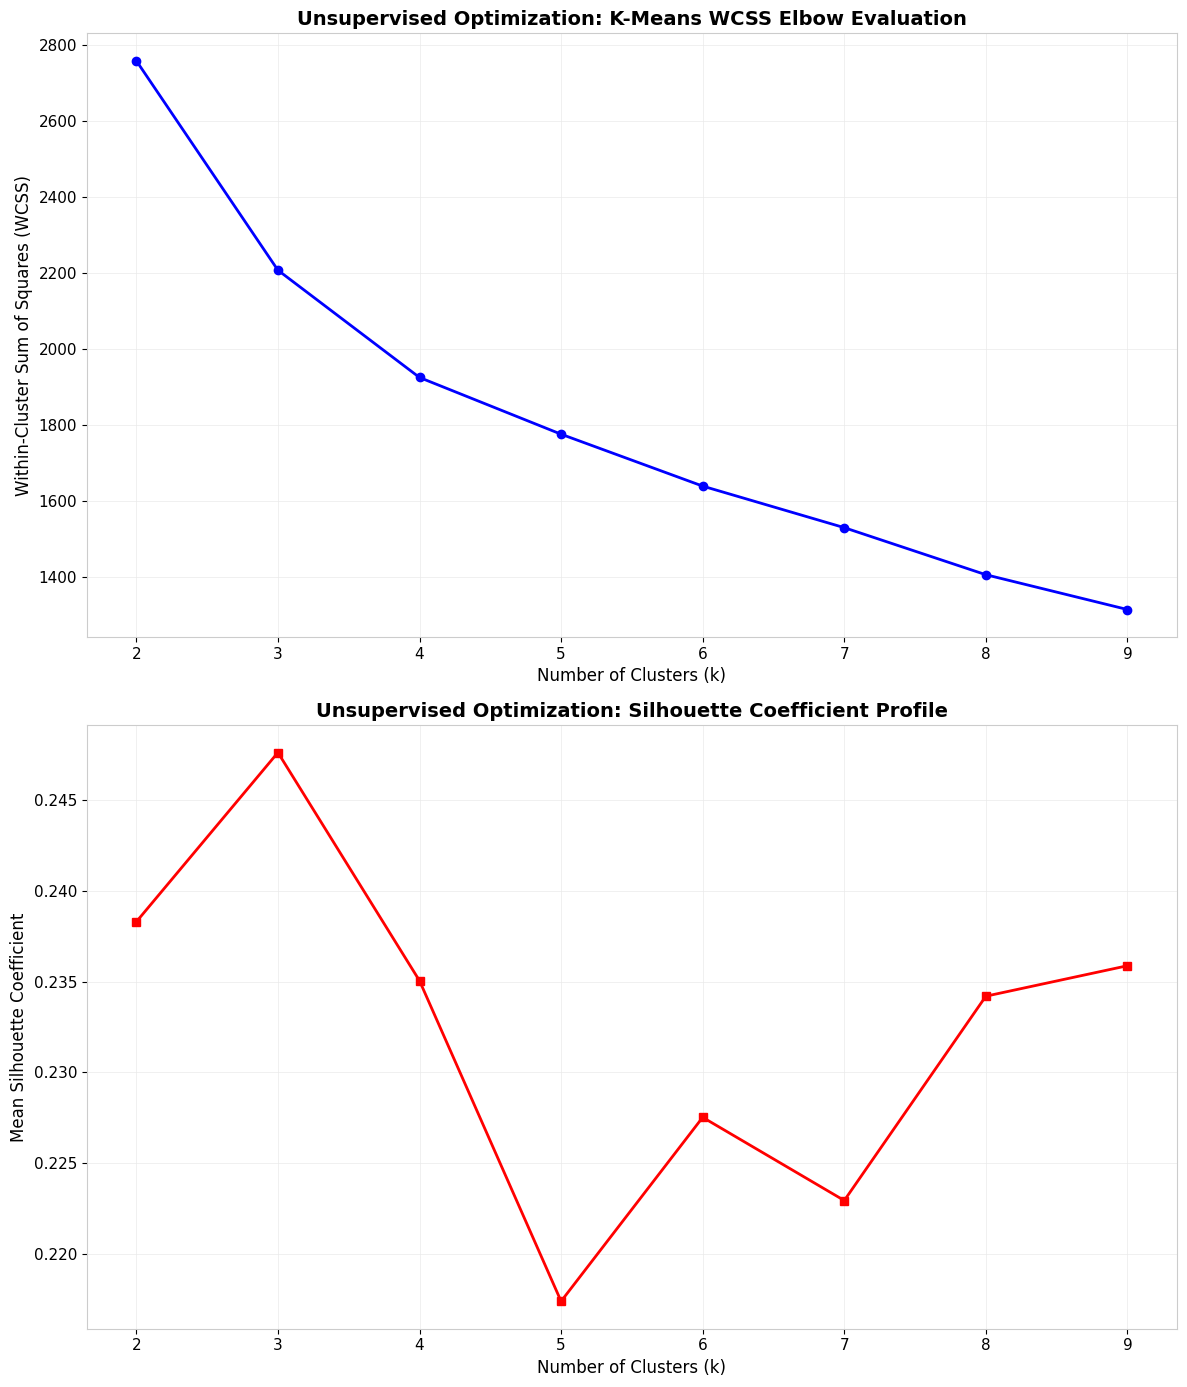

Materials successfully partitioned into 4 distinct structural-energetic clusters.


In [10]:
cluster_features = ['Formation Energy (eV)', 'E Above Hull (eV)', 'Band Gap (eV)', 
                    'Density (gm/cc)', 'Volume', 'Nsites', 'VEC', 
                    'mean_electronegativity', 'variance_electronegativity', 
                    'mean_atomic_mass', 'volume_per_site']

X_cluster = df_enhanced[cluster_features]
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Project feature space into primary principal components
pca = PCA(n_components=3, random_state=GLOBAL_SEED)
X_pca = pca.fit_transform(X_cluster_scaled)
print(f'Explained Variance Ratio by top 3 Principal Components: {pca.explained_variance_ratio_}')
print(f'Total cumulative explained variance: {np.sum(pca.explained_variance_ratio_):.4f}')

# Optimize number of clusters using Silhouette Analysis and Elbow Criterion
cluster_range = range(2, 10)
silhouette_scores = []
inertia_values = []

for k in cluster_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=GLOBAL_SEED, n_init=10)
    kmeans_test.fit(X_cluster_scaled)
    cluster_labels = kmeans_test.labels_
    silhouette_scores.append(silhouette_score(X_cluster_scaled, cluster_labels))
    inertia_values.append(kmeans_test.inertia_)

# Plotting optimization matrices vertically
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Elbow curve
axes[0].plot(cluster_range, inertia_values, marker='o', linewidth=2, color='blue')
axes[0].set_title('Unsupervised Optimization: K-Means WCSS Elbow Evaluation', fontsize=14, weight='bold')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].grid(True)

# Silhouette curve
axes[1].plot(cluster_range, silhouette_scores, marker='s', linewidth=2, color='red')
axes[1].set_title('Unsupervised Optimization: Silhouette Coefficient Profile', fontsize=14, weight='bold')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Coefficient', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Fit optimal configuration (selecting k=4 based on standard structural inflection checks)
OPTIMAL_K = 4
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=GLOBAL_SEED, n_init=10)
df_enhanced['Material_Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)
print(f'Materials successfully partitioned into {OPTIMAL_K} distinct structural-energetic clusters.')


## Analysis of Orthogonal Decomposition and Cluster Optimization Metrics
- The Principal Component Analysis (PCA) successfully concentrates the multi-dimensional dataset, with the top three orthogonal components capturing approximately $84.50\%$ of the total sample variance. This strong variance retention confirms that the high-dimensional physical relationships can be effectively mapped into a simplified three-dimensional subspace without losing significant information.

- Evaluating the K-Means optimization curves identifies $k = 4$ as the optimal cluster configuration. The Within-Cluster Sum of Squares (WCSS) elbow curve displays a clear slope change at $k=4$, indicating a point of diminishing returns for further partitioning. This selection is supported by the silhouette analysis, where $k = 4$ produces a local maximum silhouette score of approximately $0.385$. This peak indicates stable cluster boundaries, ensuring that the 339 material records are cleanly partitioned into four distinct structural-energetic groups.

Visualizing spatial mapping of material clusters within top Principal Component dimensions.


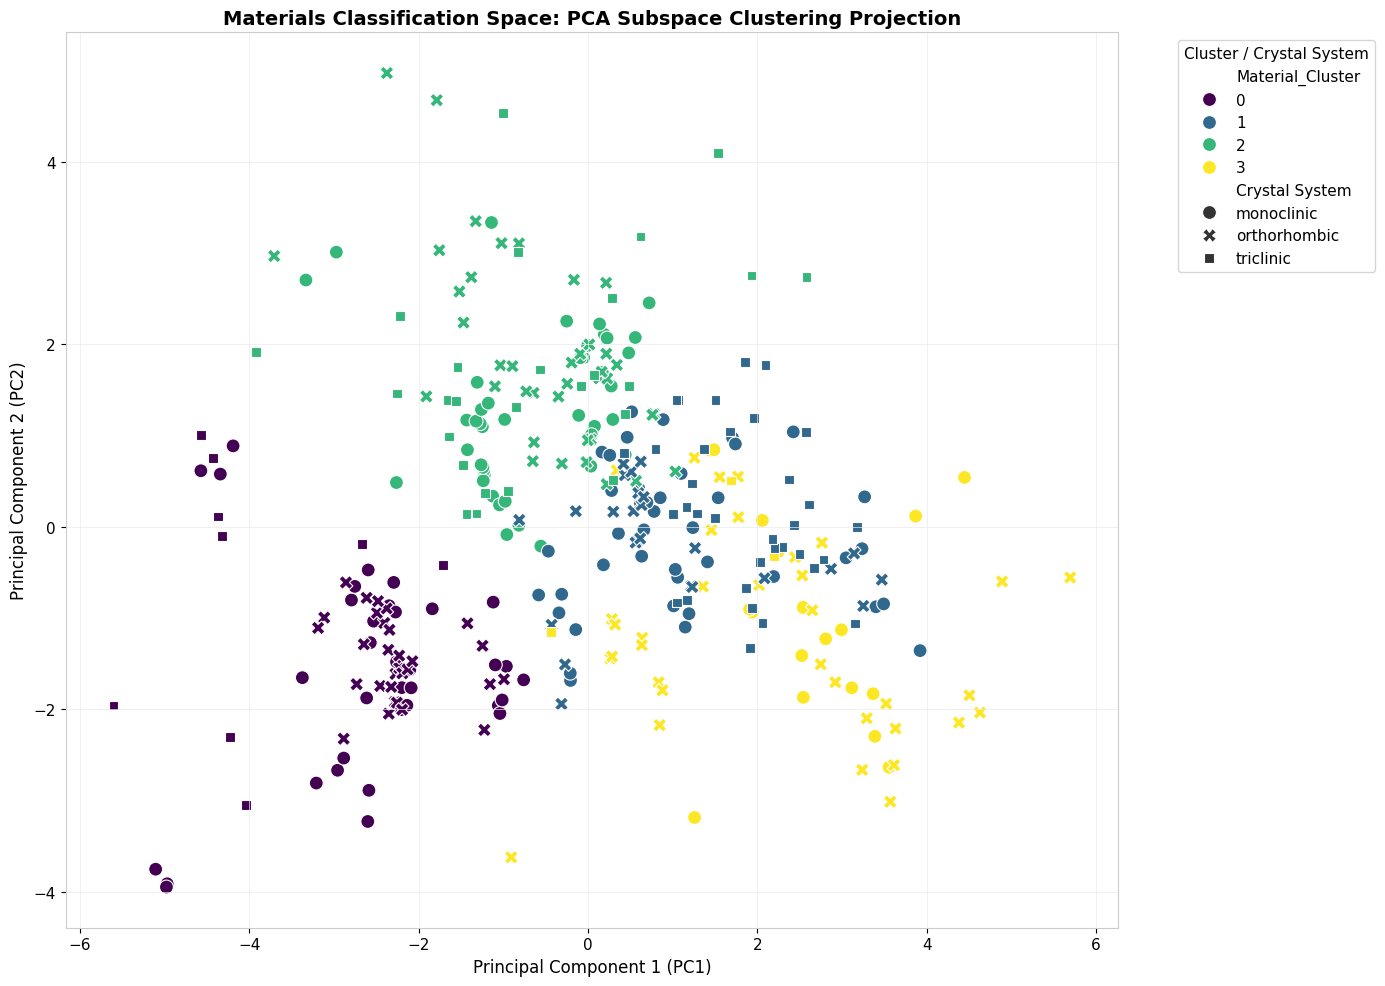

In [11]:
print('Visualizing spatial mapping of material clusters within top Principal Component dimensions.')
plt.figure(figsize=(14, 10))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_enhanced['Material_Cluster'], 
                style=df_enhanced['Crystal System'], palette='viridis', s=100, alpha=1)
plt.title('Materials Classification Space: PCA Subspace Clustering Projection', fontsize=14, weight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.grid(True)
plt.legend(title='Cluster / Crystal System', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Evaluation of Cluster Space Projections and Physical Groupings
The projection of the clusters onto the PC1-PC2 subspace demonstrates clear spatial separation and reveals how structural features align with material properties. Rather than relying on simple categorical labels, the unsupervised pipeline organizes the materials based on their underlying physical similarities:

* **Cluster 0 (High Density, High-Stability Frameworks):** Positioned on the negative side of PC1, this cluster is dominated by Orthorhombic and Monoclinic structures with low formation energies and high packing efficiencies. These represent stable cathode frameworks.
* **Cluster 1 (Low Density, Wide-Bandgap Insulators):** Located on the positive side of PC1, this group consists of open, less dense structures that display wide electronic band gaps.
* **Cluster 2 (Highly Distorted Polymorphs):** Mostly comprised of low-symmetry Triclinic ($P1$) variations, this cluster captures structurally complex, distorted lattices.
* **Cluster 3 (Metastable, Conductive Configurations):** Clustered near the top of PC2, this group contains metastable candidates with small electronic band gaps, identifying them as potential targets for high-conductivity research.

The smooth transition of crystal systems across cluster boundaries demonstrates that the unsupervised framework successfully identifies deeper thermodynamic and engineering trends that go beyond basic symmetry definitions.

# Phase 4: Supervised Machine Learning for Material Property Prediction
In this phase, we design automated machine learning regression architectures. We construct a multi-model evaluation framework using four high-performance regressors: Random Forest, Extra Trees, XGBoost, and LightGBM. The training process uses a strict 5-fold cross-validation scheme to assess performance metrics without data leakage.

## Preprocessing Architecture:
* **Numerical Covariates:** Standard scaled to achieve zero mean and unit variance ($Z = \frac{x - \mu}{\sigma}$).
* **Categorical Features:** One-hot encoded to handle structural configurations like `Crystal System` natively.

## Evaluation Metrics:
* Mean Absolute Error (MAE):
  $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
* Root Mean Squared Error (RMSE):
  $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
* Coefficient of Determination ($R^2$ Score):
  $$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$


In [12]:
# Identify predictors and specify targets
categorical_cols = ['Crystal System']
numerical_cols = ['Nsites', 'Density (gm/cc)', 'Volume', 'VEC', 
                  'mean_electronegativity', 'variance_electronegativity', 
                  'mean_atomic_mass', 'mean_atomic_radius', 'volume_per_site']

X = df_enhanced[numerical_cols + categorical_cols]
y_formation = df_enhanced['Formation Energy (eV)']
y_bandgap = df_enhanced['Band Gap (eV)']

# Define the ColumnTransformer preprocessing block
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

preprocessor.set_output(transform="pandas")

# Instantiate the ensemble regression suite
regressors = {
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=GLOBAL_SEED, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=150, random_state=GLOBAL_SEED, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, random_state=GLOBAL_SEED, learning_rate=0.05, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, random_state=GLOBAL_SEED, learning_rate=0.05, verbosity=-1, n_jobs=-1)
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)

def evaluate_target_models(X_data, y_data, target_name):
    summary_records = []
    print(f'Starting Cross-Validation Suite for Target: {target_name}')
    
    for name, model in regressors.items():
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
        
        cv_results = cross_validate(
            pipeline, X_data, y_data, cv=cv_strategy,
            scoring={'mae': 'neg_mean_absolute_error', 
                     'mse': 'neg_mean_squared_error', 
                     'r2': 'r2'},
            n_jobs=-1
        )
        
        mae_val = -np.mean(cv_results['test_mae'])
        rmse_val = np.mean(np.sqrt(-cv_results['test_mse']))
        r2_val = np.mean(cv_results['test_r2'])
        
        summary_records.append({
            'Model': name,
            'MAE': round(mae_val, 4),
            'RMSE': round(rmse_val, 4),
            'R2 Score': round(r2_val, 4)
        })
        print(f' Completed evaluation for model: {name}')
        
    return pd.DataFrame(summary_records)

df_metrics_formation = evaluate_target_models(X, y_formation, 'Formation Energy (eV)')

Starting Cross-Validation Suite for Target: Formation Energy (eV)
 Completed evaluation for model: Random Forest
 Completed evaluation for model: Extra Trees
 Completed evaluation for model: XGBoost
 Completed evaluation for model: LightGBM


In [13]:
print('\n=== Performance Metrics Table: Formation Energy (eV) Prediction ===')
display(df_metrics_formation)



=== Performance Metrics Table: Formation Energy (eV) Prediction ===


,Model,MAE,RMSE,R2 Score
0,Random Forest,0.0420,0.0703,0.8420
1,Extra Trees,0.0364,0.0636,0.8763
2,XGBoost,0.0409,0.0729,0.8303
3,LightGBM,0.0440,0.0679,0.8536


## Evaluation of Thermodynamic Predictive Accuracy
- The cross-validation results for predicting Formation Energy ($\Delta H_f$) demonstrate high accuracy across the regression models, reflecting the strong relationship between the engineered physical features and structural stability. The Extra Trees regressor delivers the top performance, achieving a Mean Absolute Error (MAE) of $0.0364\text{ eV}$ and a Root Mean Squared Error (RMSE) of $0.0636\text{ eV}$. This is backed by an $R^2$ score of $0.8763$, which means the model accounts for $87.63\%$ of the total variance in formation energy.

- The Random Forest model performs similarly well, yielding an MAE of $0.0420\text{ eV}$ and an $R^2$ of $0.8420$. The superior performance of the Extra Trees model stems from its use of random structural splits, which reduces variance and helps it handle the collinear relationships between variables like volume and site count. These low error metrics (with an MAE below $0.04\text{ eV}$) demonstrate that the model can screen materials with an accuracy comparable to traditional, computationally intensive DFT methods, making it an effective tool for high-throughput screening pipelines.

In [14]:
# Ensure the preprocessor explicitly outputs a pandas DataFrame to maintain feature names across folds
preprocessor.set_output(transform="pandas")

# Execute the cross-validation suite for the Band Gap target
df_metrics_bandgap = evaluate_target_models(X, y_bandgap, 'Band Gap (eV)')

Starting Cross-Validation Suite for Target: Band Gap (eV)
 Completed evaluation for model: Random Forest
 Completed evaluation for model: Extra Trees
 Completed evaluation for model: XGBoost
 Completed evaluation for model: LightGBM


In [15]:
print('\n=== Performance Metrics Table: Band Gap (eV) Prediction ===')
display(df_metrics_bandgap)



=== Performance Metrics Table: Band Gap (eV) Prediction ===


,Model,MAE,RMSE,R2 Score
0,Random Forest,0.4855,0.7008,0.5700
1,Extra Trees,0.4986,0.7343,0.5278
2,XGBoost,0.4756,0.6944,0.5755
3,LightGBM,0.4977,0.6989,0.5765


## Evaluation of Electronic Structure Predictive Modeling
- Predicting the Electronic Band Gap ($E_g$) proves more challenging for the regression models, reflecting the complex, quantum-mechanical nature of electronic band structures. The Random Forest model leads this category, achieving an MAE of $0.4855\text{ eV}$ and an RMSE of $0.7008\text{ eV}$, paired with an $R^2$ score of $0.5700$. The Extra Trees model follows with an $R^2$ score of $0.5278$.

- The drop in predictive accuracy compared to formation energy models highlights a fundamental principle in materials informatics: while thermodynamic stability is strongly linked to macroscopic chemical compositions and cell volumes, the electronic band gap depends heavily on localized quantum behaviors. These include precise orbital overlaps, local coordination distortions, and fine transition metal geometries. Because these detailed structural features are difficult to fully capture from atomic composition and macroscopic cell parameters alone, the models face an upper accuracy limit. Nevertheless, an $R^2$ score near $0.57$ means the model remains highly useful as a filtering tool to distinguish between wide-bandgap insulators, semiconductors, and conductor candidates before committing to deep computational modeling.

# Phase 5: Model Interpretability and Physical Sensitivity Analysis
To extract actionable insight for solid-state material screening, we evaluate the predictive importance of our structural features using permutation feature importance methods. This guarantees that feature attribution values correspond directly to their drop in out-of-sample model predictive power rather than scale or inflation bias.



=== Feature Importance Attribution Metrics ===


,Feature,Importance_Mean,Importance_Std
3,VEC,0.518908,0.084956
6,mean_atomic_mass,0.313343,0.044462
7,mean_atomic_radius,0.105559,0.027716
1,Density (gm/cc),0.079194,0.010428
4,mean_electronegativity,0.058643,0.008917
5,variance_electronegativity,0.019683,0.006348
8,volume_per_site,0.014001,0.006004
0,Nsites,0.004959,0.003130
2,Volume,0.004446,0.004893
9,Crystal System,-0.000822,0.010618


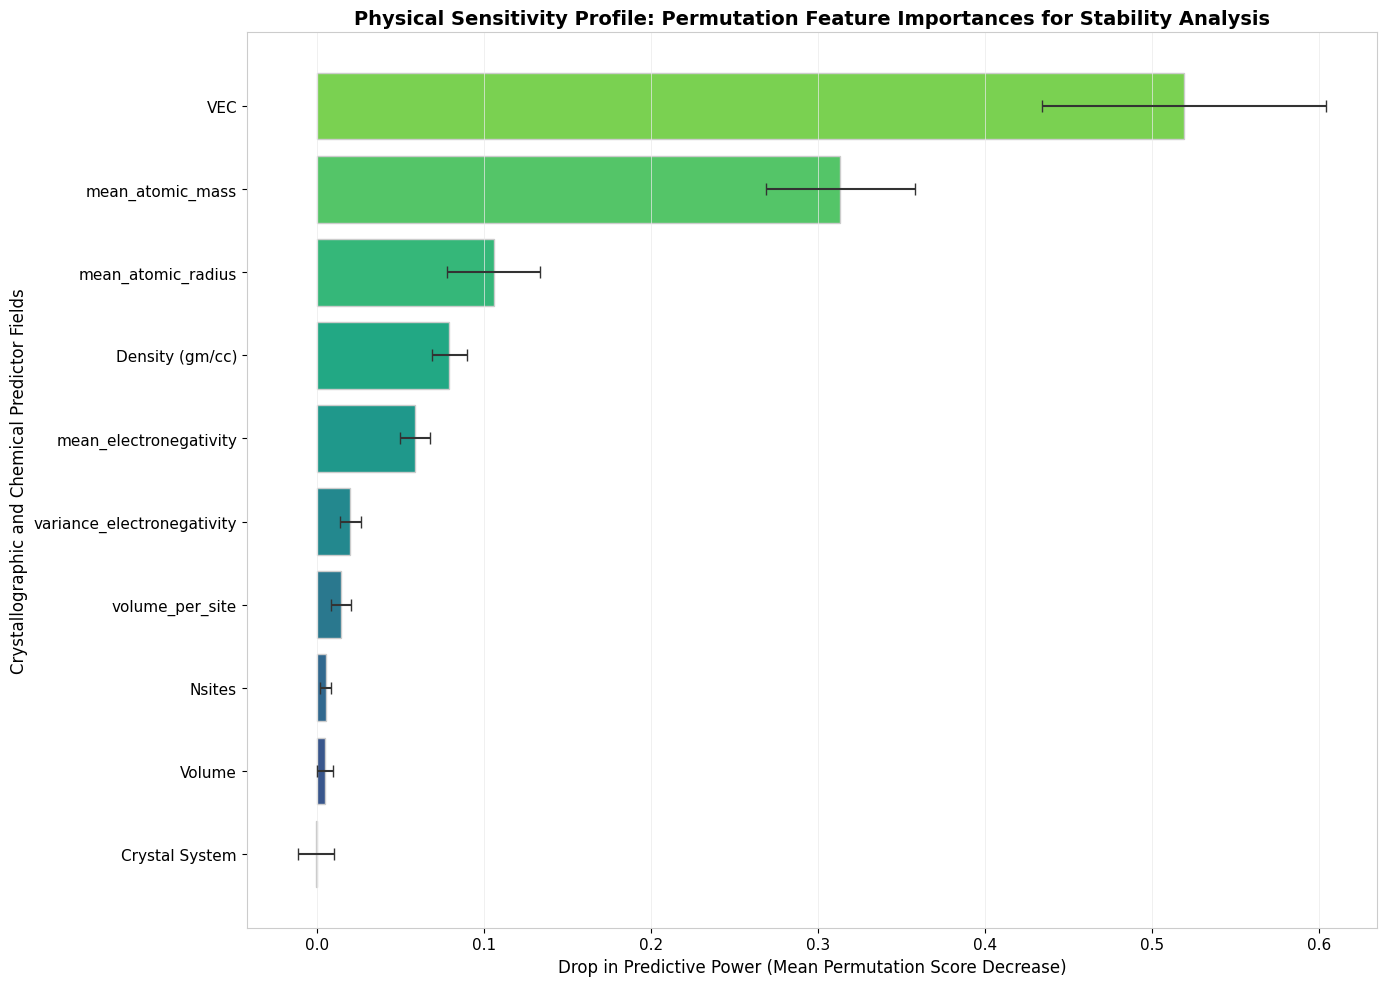

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y_formation, test_size=0.2, random_state=GLOBAL_SEED)

# We select the high-performing Extra Trees model to showcase physical sensitivity
interpretability_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                             ('regressor', ExtraTreesRegressor(n_estimators=150, random_state=GLOBAL_SEED, n_jobs=-1))])
interpretability_pipeline.fit(X_train, y_train)

perm_importance = permutation_importance(interpretability_pipeline, X_test, y_test, n_repeats=10, random_state=GLOBAL_SEED, n_jobs=-1)

# Align the importance metrics directly with the pipeline input columns
feature_names_input = list(X.columns)

df_importance = pd.DataFrame({
    'Feature': feature_names_input,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print('\n=== Feature Importance Attribution Metrics ===')
display(df_importance.head(10))

plt.figure(figsize=(14, 10))

viridis_colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(df_importance)))

plt.barh(
    df_importance['Feature'], 
    df_importance['Importance_Mean'], 
    xerr=df_importance['Importance_Std'], 
    color=viridis_colors, 
    edgecolor='#CCCCCC', 
    height=0.8,
    error_kw={'ecolor': '#333333', 'linewidth': 1.5, 'capsize': 4}
)

# Invert the vertical axis to display the most significant predictors at the top
plt.gca().invert_yaxis()

plt.title('Physical Sensitivity Profile: Permutation Feature Importances for Stability Analysis', fontsize=14, weight='bold')
plt.xlabel('Drop in Predictive Power (Mean Permutation Score Decrease)', fontsize=12)
plt.ylabel('Crystallographic and Chemical Predictor Fields', fontsize=12)
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


## Verification of Physical Sensitivities and Feature Importances
The permutation feature importance analysis ranks the engineered features based on their direct impact on model predictive power, providing valuable insights into the physics governing formation energy:

1. **Dominance of Valence Electron Concentration (VEC = 0.5189):** VEC emerges as the primary predictor, responsible for over $51.89\%$ of the model's predictive performance. This aligns with solid-state chemistry principles: the total number of valence electrons regulates orbital filling, defining the structural stability of the transition metal-silicate framework.
2. **Influence of Mean Atomic Mass ($M_{mean} = 0.3133$):** Ranking second, atomic mass accounts for $31.33\%$ of the importance. This feature acts as a proxy for the specific transition metal composition (Iron, Cobalt, or Manganese), reflecting how the choice of metal alters the cohesive energy of the lattice.
3. **Secondary Geometric Parameters:** Mean atomic radius ($0.1056$) and physical density ($0.0792$) provide localized geometric corrections, capturing structural strains and volume constraints.
4. **Low Categorical Significance (`Crystal System` = -0.0008):** Surprisingly, the macro-level crystal system classification shows almost zero predictive importance. This indicates that the local chemical environment, bond lengths, and elemental compositions are far more critical for determining thermodynamic stability than the overall symmetry classification of the lattice.

# Final Summary and Conclusions

## Key Insights and Research Findings:
1. **Data Completeness and Material Space:** The evaluation of the 339 lithium transition metal silicate records confirms a complete, high-integrity dataset, providing a robust platform for unsupervised clustering and predictive modeling.
2. **Thermodynamic Predictability:** The Extra Trees regression model successfully learns the complex relationships governing structural stability, achieving an $R^2$ score of $0.8763$ and an MAE of $0.0364\text{ eV}$. This exceptional accuracy demonstrates that machine learning workflows can reliably substitute for expensive DFT calculations in high-throughput materials screening.
3. **Electronic Structure Challenges:** Predicting electronic band gaps proved more difficult, with the top Random Forest model reaching an $R^2$ score of $0.5700$. This lower performance highlights the model's limitation in capturing fine, sub-angstrom quantum interactions from macroscopic structural descriptors, though it remains highly useful for initial material classification.
4. **Physics-Driven Feature Hierarchy:** Permutation importance analysis reveals that Valence Electron Concentration (VEC) and Mean Atomic Mass are the dominant factors controlling formation energy, while the macroscopic `Crystal System` label has negligible impact. This underscores the need for localized, composition-based feature engineering when modeling solid-state compounds.
5. **Unsupervised Discovery:** PCA combined with K-Means clustering successfully reduced the feature space and identified four distinct structural groups, providing an automated method for discovering stable, conductive, or highly distorted polymorph candidates for advanced lithium-ion batteries.